In [43]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from xgboost import XGBRegressor

In [44]:
df=pd.read_csv("ds_job_salary.csv")
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [45]:
df.shape

(607, 12)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [47]:
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [48]:
#Check Missing Values
df.isnull().sum()

Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [49]:
df["job_country"] = df["job_title"] + "_" + df["company_location"]

df["same_country"] = (df["employee_residence"] == df["company_location"]).astype(int)

In [50]:
# Job title encoding
job_mean = df.groupby("job_title")["salary_in_usd"].mean()
df["job_encoded"] = df["job_title"].map(job_mean)

# Job + country encoding (VERY POWERFUL)
job_country_mean = df.groupby("job_country")["salary_in_usd"].mean()
df["job_country_encoded"] = df["job_country"].map(job_country_mean)

# Company location encoding
loc_mean = df.groupby("company_location")["salary_in_usd"].mean()
df["company_encoded"] = df["company_location"].map(loc_mean)

In [51]:
df["experience_level"] = df["experience_level"].map({
"EN":1,"MI":2,"SE":3,"EX":4
})

df["company_size"] = df["company_size"].map({
"S":1,"M":2,"L":3
})

df["employment_type"] = df["employment_type"].map({
"PT":1,"FT":2,"CT":3,"FL":4
})

In [52]:
df = df.drop(columns=[
    "job_title",
    "employee_residence",
    "company_location",
    "job_country",
    "salary_currency"   # ✅ ADD THIS
])

In [53]:
df["salary_in_usd"] = np.log1p(df["salary_in_usd"])

In [54]:
print(X.dtypes)

Unnamed: 0               int64
work_year                int64
experience_level         int64
employment_type          int64
salary                   int64
salary_currency         object
remote_ratio             int64
company_size             int64
same_country             int64
job_encoded            float64
job_country_encoded    float64
company_encoded        float64
dtype: object


In [55]:
X = df.drop("salary_in_usd", axis=1)
y = df["salary_in_usd"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [56]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=12,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.2,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [68]:
print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.9541271170131457


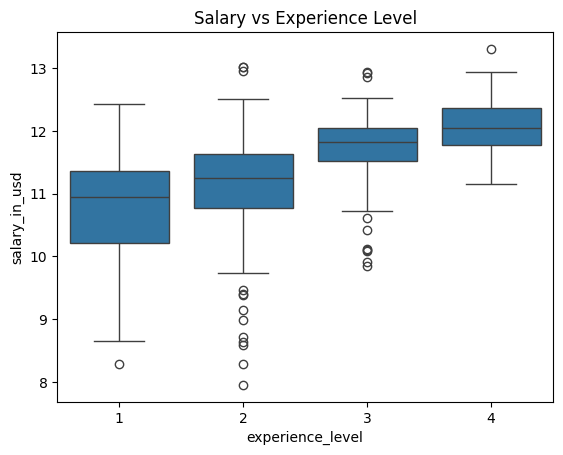

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(x="experience_level", y="salary_in_usd", data=df)
plt.title("Salary vs Experience Level")
plt.show()

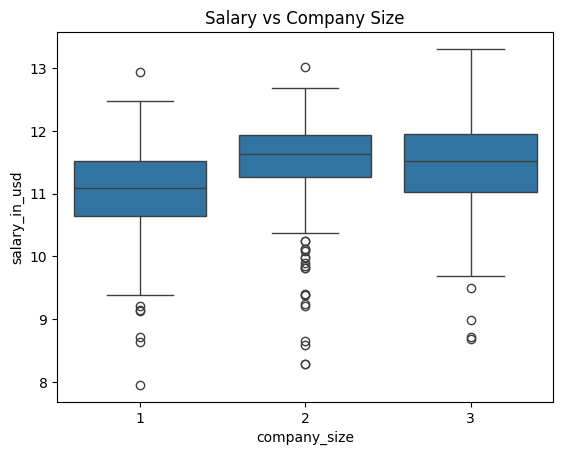

In [70]:
plt.figure()
sns.boxplot(x="company_size", y="salary_in_usd", data=df)
plt.title("Salary vs Company Size")
plt.show()

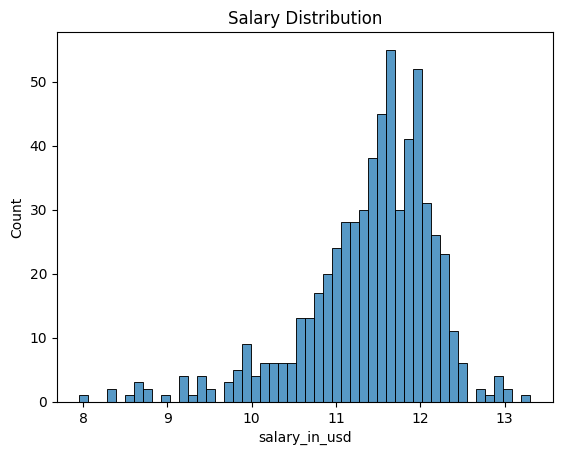

In [60]:
plt.figure()
sns.histplot(df["salary_in_usd"], bins=50)
plt.title("Salary Distribution")
plt.show()

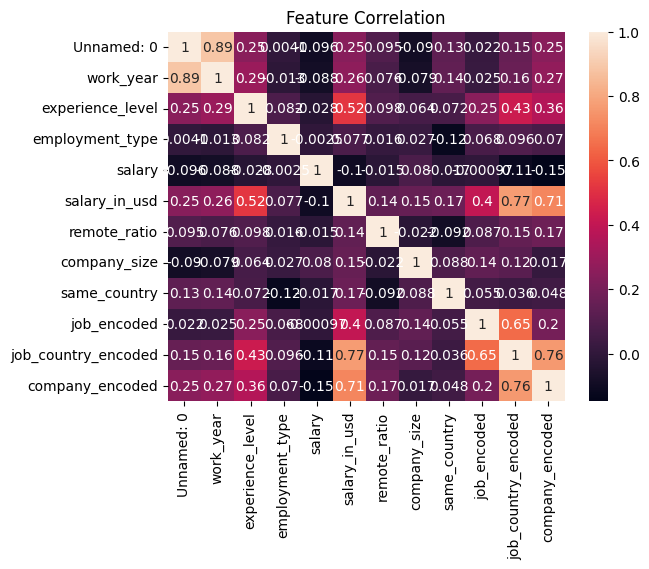

In [61]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

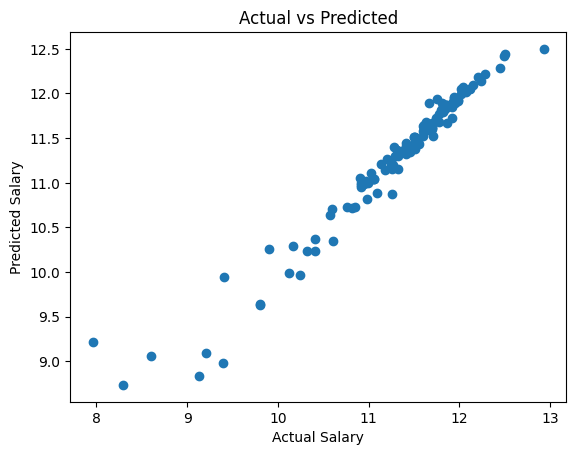

In [62]:
plt.figure()
plt.scatter(y_test, pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

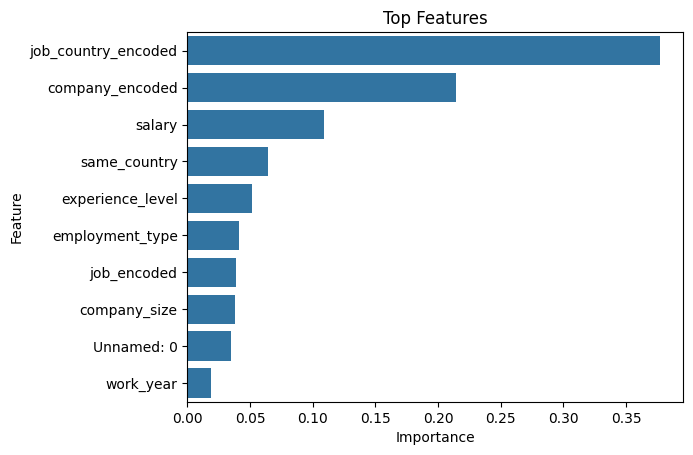

In [63]:
import pandas as pd

importance = model.feature_importances_

imp_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure()
sns.barplot(x="Importance", y="Feature", data=imp_df.head(10))
plt.title("Top Features")
plt.show()